# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, poisson, binom
import statistics
import warnings



warnings.filterwarnings('ignore')

# Loading Dataset

In [2]:
df = pd.read_csv('social_media_engagement1.csv')

In [ ]:
#. data["EDAD"] = pd.to_numeric(data["EDAD"],errors="coerce")

#. Limpieza de datos...
#. Filtramos y damos formato de fecha
df["post_time"] = pd.to_datetime(df["post_time"],errors="coerce")

df.head(100)

0    2023-08-17 14:45:00
1    2023-05-14 00:45:00
2    2023-02-21 16:15:00
3    2023-11-16 00:45:00
4    2023-05-23 00:30:00
             ...        
95   2023-07-12 17:45:00
96   2023-10-27 23:45:00
97   2023-08-05 08:45:00
98   2023-12-29 12:15:00
99   2023-06-06 21:00:00
Name: post_time, Length: 100, dtype: datetime64[us]

platform
Instagram    36
Facebook     32
Twitter      32
Name: count, dtype: int64


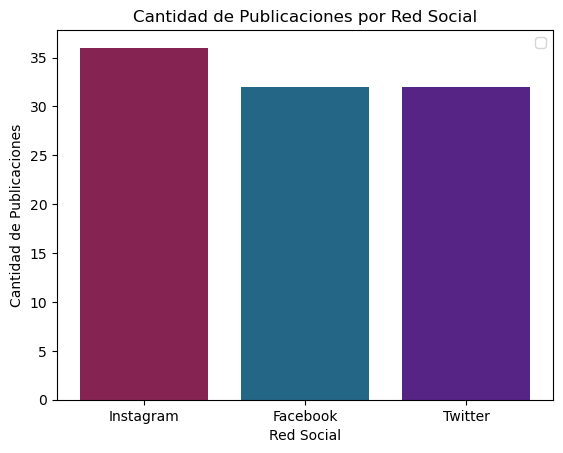

In [6]:
#. Cantidad de Post por Red Social
frecuencias = df['platform'].value_counts()
colores = ["#852453","#246685","#552485"]

print(frecuencias)

plt.figure()
plt.bar(frecuencias.index, frecuencias.values, color=colores)
plt.title("Cantidad de Publicaciones por Red Social")
plt.xlabel("Red Social")
plt.ylabel("Cantidad de Publicaciones")
plt.legend()
plt.show()

[[7, 9, 6, 7, 7], [4, 10, 3, 9, 6], [6, 7, 4, 7, 8]]


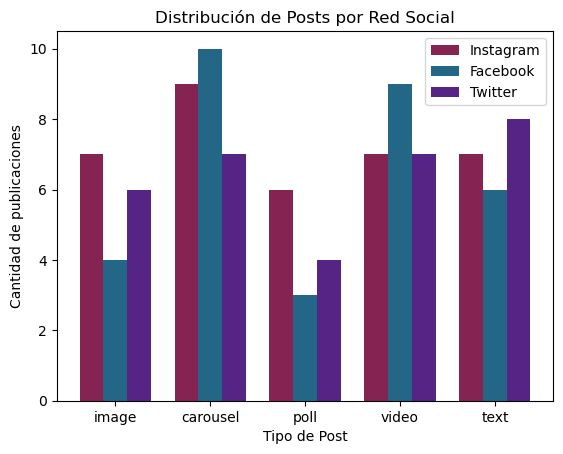

In [9]:
#. Tipo de post por red social
psxrs = [[0 for _ in range(5)] for _ in range(3)] 
ps = ["image" , "carousel" , "poll" , "video" , "text" ] #. tipo de post (columnas)
rs = ["Instagram" , "Facebook" , "Twitter"] #. tipo de red social (filas)

for indice, fila in df.iterrows():
        try:
            fila_idx = rs.index(fila["platform"])
            col_idx = ps.index(fila["post_type"])

            psxrs[fila_idx][col_idx] += 1
        except ValueError:
              continue
print(psxrs)

#. Gráfica de Barras Adyacentes
datos = np.array(psxrs)
x = np.arange(len(ps))
width = 0.25

plt.bar(x - width, datos[0], width=width, label=rs[0], color="#852453") # Instagram
plt.bar(x, datos[1], width=width, label=rs[1], color="#246685") # Facebook
plt.bar(x + width, datos[2], width=width, label=rs[2],color="#552485") #Twitter
plt.xlabel("Tipo de Post")
plt.ylabel("Cantidad de publicaciones")
plt.title("Distribución de Posts por Red Social")
plt.xticks(x, ps)
plt.legend()
plt.show()

post_day
Wednesday    18
Thursday     16
Friday       16
Tuesday      15
Sunday       14
Monday       11
Saturday     10
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

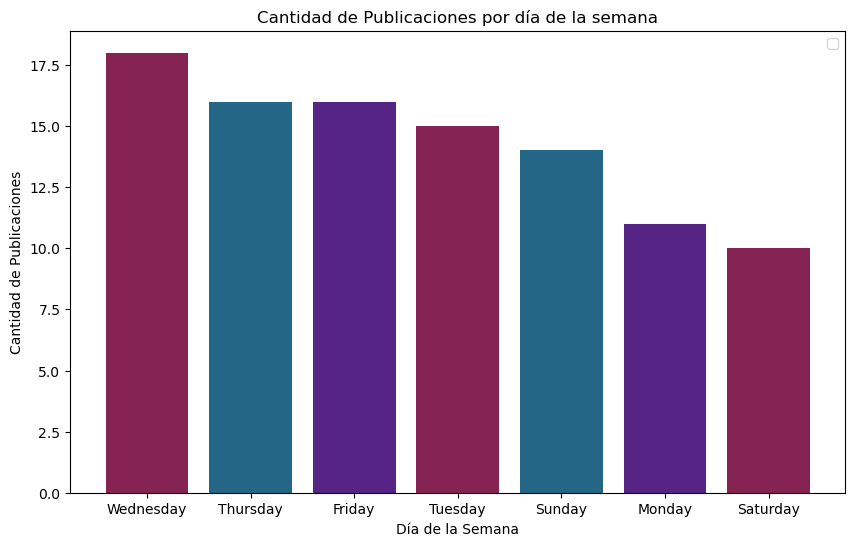

In [7]:
#. Día de la semana con más publicaciones (ordenadas DES)
frecuencias = df['post_day'].value_counts()
colores = ["#852453","#246685","#552485"]

print(frecuencias)

plt.figure()
plt.figure(figsize=(10, 6))
plt.bar(frecuencias.index, frecuencias.values, color=colores)
plt.title("Cantidad de Publicaciones por día de la semana")
plt.xlabel("Día de la Semana")
plt.ylabel("Cantidad de Publicaciones")
plt.legend()
plt.show()

Día de la semana con más reacciones positivas: Wednesday (11) 


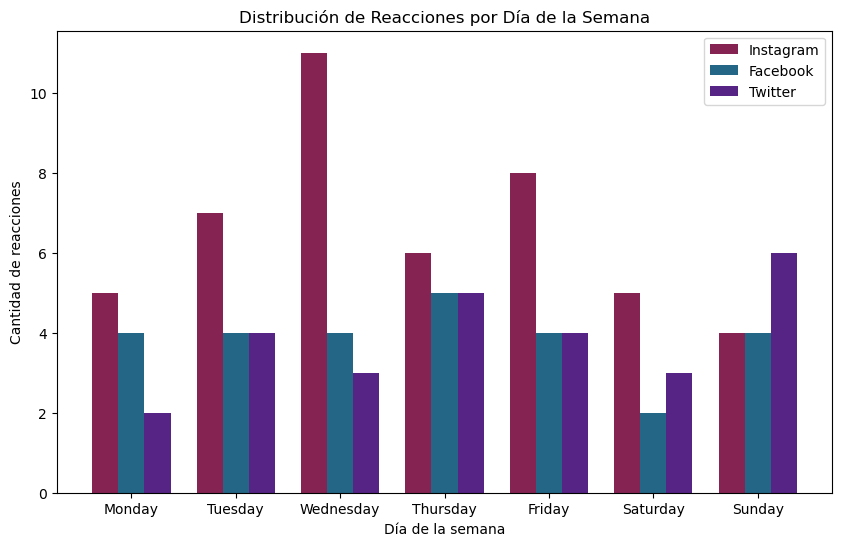

In [11]:
#. Día de la semana con reacción positiva
dsxrp = [[0 for _ in range(7)] for _ in range(3)] 
ds = ["Monday" , "Tuesday" , "Wednesday" , "Thursday" , "Friday", "Saturday", "Sunday" ] #. día de la semana (columnas)
rc = ["positive" , "neutral" , "negative"] #. tipo de reacción (filas)

for indice, fila in df.iterrows():
        try:
            fila_idx = rc.index(fila["sentiment_score"])
            col_idx = ds.index(fila["post_day"])

            dsxrp[fila_idx][col_idx] += 1
        except ValueError:
              continue
#. print(dsxrp)

maxN = max(dsxrp[0])
maxD = ds[dsxrp[0].index(maxN)]
print(f"Día de la semana con más reacciones positivas: {maxD} ({maxN}) ")

#. Gráfica de Barras Adyacentes
datos = np.array(dsxrp)
x = np.arange(len(ds))
width = 0.25
plt.figure(figsize=(10, 6))
plt.bar(x - width, datos[0], width=width, label=rs[0], color="#852453") # Positiva
plt.bar(x, datos[1], width=width, label=rs[1], color="#246685") # Neutral
plt.bar(x + width, datos[2], width=width, label=rs[2],color="#552485") # Negativa
plt.xlabel("Día de la semana")
plt.ylabel("Cantidad de reacciones")
plt.title("Distribución de Reacciones por Día de la Semana")
plt.xticks(x, ds)
plt.legend()
plt.show()

Momento del día con más reacciones positivas: Night (21)


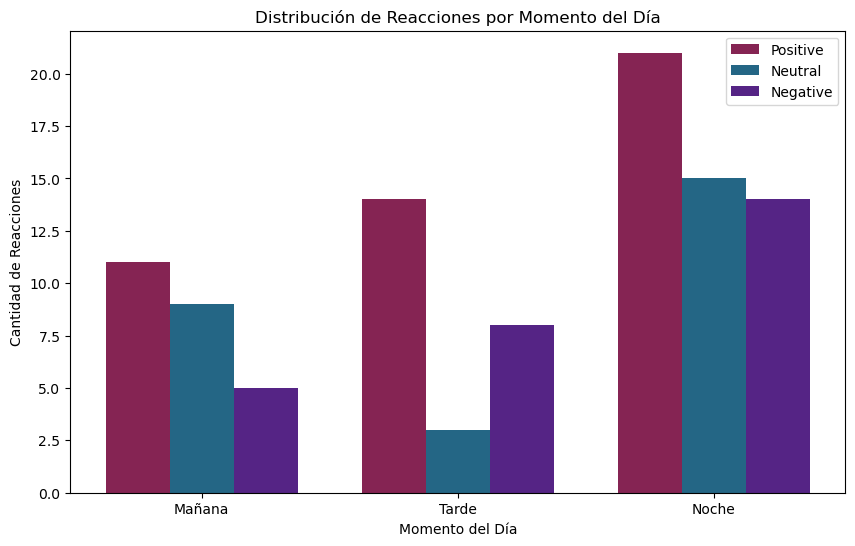

In [12]:
#. Momento del día con reacciones positivas (mañana, tarde, noche)
mdrp = [[0 for _ in range(3)] for _ in range(3)]

momentos = ["Morning", "Afternoon", "Night"] 
rc = ["positive", "neutral", "negative"] 

for indice, fila in df.iterrows():
    try:
        hora = fila["post_time"].hour
        
        if hora >= 6 and hora < 12:
            momento = "Morning"
        elif hora >= 12 and hora < 18:
            momento = "Afternoon"
        else:
            momento = "Night"

        fila_idx = rc.index(fila["sentiment_score"])
        col_idx = momentos.index(momento)

        mdrp[fila_idx][col_idx] += 1

    except:
        continue

#. Momento del día con más reacciones positivas
maxN = max(mdrp[0])
maxM = momentos[mdrp[0].index(maxN)]

print(f"Momento del día con más reacciones positivas: {maxM} ({maxN})")

#. Gráfica de Barras 
datos = np.array(mdrp)
x = np.arange(len(momentos))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, datos[0], width=width, label="Positive", color="#852453")
plt.bar(x, datos[1], width=width, label="Neutral", color="#246685")
plt.bar(x + width, datos[2], width=width, label="Negative", color="#552485")
plt.xlabel("Momento del Día")
plt.ylabel("Cantidad de Reacciones")
plt.title("Distribución de Reacciones por Momento del Día")
plt.xticks(x, ["Mañana", "Tarde", "Noche"])
plt.legend()
plt.show()

Red social con más sentimientos negativos: Instagram (14)


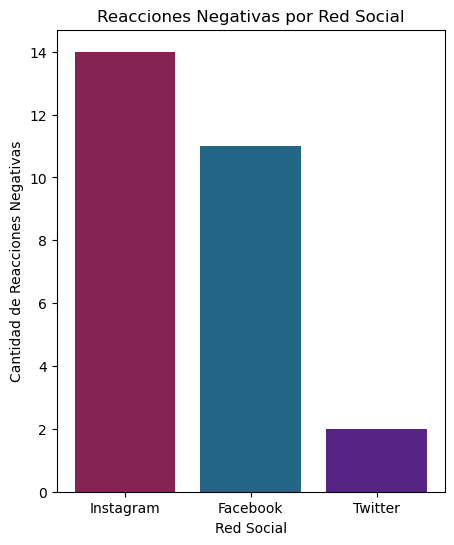

In [13]:
#. ¿Qué red social tiene más sentimientos negativos?
rsn = [0 for _ in range(3)]
rs = ["Instagram", "Facebook", "Twitter"]

for indice, fila in df.iterrows():
    try:
        if fila["sentiment_score"] == "negative":
            fila_idx = rs.index(fila["platform"])
            rsn[fila_idx] += 1
    except ValueError:
        continue

maxN = max(rsn)
maxRS = rs[rsn.index(maxN)]

print(f"Red social con más sentimientos negativos: {maxRS} ({maxN})")

#. Gráfica de Barras
plt.figure(figsize=(5,6))
colores = ["#852453", "#246685", "#552485"]
plt.bar(rs, rsn, color=colores)
plt.xlabel("Red Social")
plt.ylabel("Cantidad de Reacciones Negativas")
plt.title("Reacciones Negativas por Red Social")
plt.show()

[[7, 11, 7, 9, 12], [5, 6, 2, 9, 5], [5, 9, 4, 5, 4]]


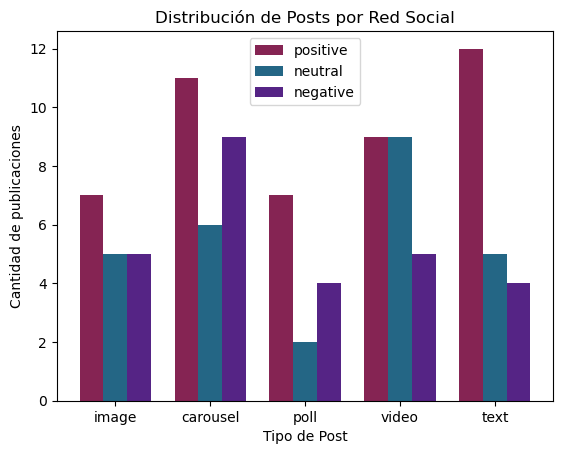

In [16]:
#. ¿Qué sentimiento genera cada tipo de post?
rcxps = [[0 for _ in range(5)] for _ in range(3)] 
ps = ["image" , "carousel" , "poll" , "video" , "text" ] #. tipo de post (columnas)
rc = ["positive" , "neutral" , "negative"] #. tipo de reacción (filas)

for indice, fila in df.iterrows():
        try:
            fila_idx = rc.index(fila["sentiment_score"])
            col_idx = ps.index(fila["post_type"])

            rcxps[fila_idx][col_idx] += 1
        except ValueError:
              continue
print(rcxps)

#. Gráfica de Barras Adyacentes
datos = np.array(rcxps)
x = np.arange(len(ps))
width = 0.25

plt.bar(x - width, datos[0], width=width, label=rc[0], color="#852453") # Instagram
plt.bar(x, datos[1], width=width, label=rc[1], color="#246685") # Facebook
plt.bar(x + width, datos[2], width=width, label=rc[2],color="#552485") #Twitter
plt.xlabel("Tipo de Post")
plt.ylabel("Cantidad de publicaciones")
plt.title("Distribución de Posts por Red Social")
plt.xticks(x, ps)
plt.legend()
plt.show()

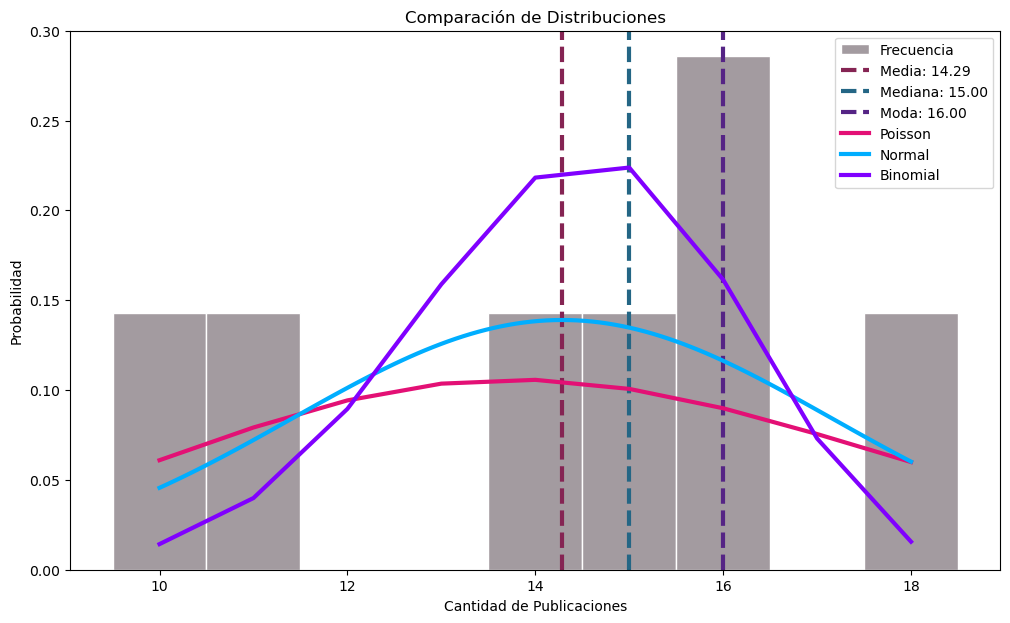

In [14]:
#. Distribución de publicaciones por día 
frecuencias = df['post_day'].value_counts()
mu = frecuencias.mean()
med = frecuencias.median()
moda = statistics.mode(frecuencias)
sigma = frecuencias.std()
n = frecuencias.max()
p = mu / n



#Gráfico de barras
plt.figure(figsize=(12, 7))
plt.hist(frecuencias, bins=np.arange(frecuencias.min(), frecuencias.max() + 2) -0.5, density=True, color="#A39BA0", edgecolor='white', label='Frecuencia')

x = np.arange(int(frecuencias.min()), int(frecuencias.max()) + 1)

#Media, moda y mediana
plt.axvline(mu, color='#852453', linestyle='--', lw=3, label=f'Media: {mu:.2f}')
plt.axvline(med, color='#246685', linestyle='--', lw=3, label=f'Mediana: {med:.2f}')
plt.axvline(moda, color='#552485', linestyle='--', lw=3, label=f'Moda: {moda:.2f}')

#Poisson
plt.plot(x, poisson.pmf(x, mu), label='Poisson', color='#E31075', lw=3)

#Normal
x_norm = np.linspace(frecuencias.min(), frecuencias.max(), 100)
plt.plot(x_norm, norm.pdf(x_norm, mu, sigma), label='Normal', color='#00AEFF', lw=3)

#Binomial
plt.plot(x, binom.pmf(x, n, p), label='Binomial', color='#8000FF', lw=3)

plt.title('Comparación de Distribuciones')
plt.xlabel('Cantidad de Publicaciones')
plt.ylabel('Probabilidad')
plt.legend()
plt.show()